# Deskewing obrazu za pomocą momentów geometrycznych

## Cel metody

Celem metody **deskewingu** (korekcji przekrzywienia) jest **usunięcie nachylenia obiektu** w obrazie — na przykład cyfry, litery lub tekstu — tak, aby jego główna oś była wyrównana w pionie lub poziomie.  
Pozwala to poprawić skuteczność dalszego przetwarzania, np. segmentacji, klasyfikacji lub rozpoznawania tekstu (OCR).

---

## Podstawy teoretyczne — momenty geometryczne

Moment geometryczny rzędu *(p, q)* dla obrazu ciągłego definiuje się jako:

$$
m_{pq} = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} x^p y^q f(x, y) \, dx \, dy
$$

Dla obrazu dyskretnego (macierzy pikseli):

$$
m_{pq} = \sum_x \sum_y x^p y^q f(x, y)
$$

gdzie:
- $ f(x, y) $ — wartość intensywności piksela (np. w skali szarości),
- $ p, q $ — rzędy momentów (liczby całkowite nieujemne).

---

## Środek masy (centroid)

Moment zerowego rzędu $ m_{00} $ odpowiada **sumie wszystkich intensywności**:

$$
m_{00} = \sum_x \sum_y f(x, y)
$$

Współrzędne **środka masy (centroidu)** oblicza się jako:

$$
\bar{x} = \frac{m_{10}}{m_{00}}, \quad \bar{y} = \frac{m_{01}}{m_{00}}
$$

---

## Momenty centralne

Aby usunąć zależność od położenia obiektu w obrazie, wprowadza się **momenty centralne**, definiowane względem środka masy:

$$
\mu_{pq} = \sum_x \sum_y (x - \bar{x})^p (y - \bar{y})^q f(x, y)
$$

Momenty centralne opisują **kształt** obiektu niezależnie od jego położenia.

---

## Wyznaczanie kąta nachylenia obiektu

Z momentów drugiego rzędu ($ \mu_{20}, \mu_{02}, \mu_{11} $) można wyznaczyć **główną oś inercji** kształtu — czyli kierunek, w którym obiekt jest wydłużony.

Kąt tej osi (względem osi poziomej) oblicza się ze wzoru:

$$
\tan(2\theta) = \frac{2 \mu_{11}}{\mu_{20} - \mu_{02}}
$$

Stąd:

$$
\theta = \frac{1}{2} \arctan \left( \frac{2 \mu_{11}}{\mu_{20} - \mu_{02}} \right)
$$

Ten kąt opisuje **nachylenie obiektu** względem osi układu współrzędnych.

---

## Korekcja przekrzywienia (deskewing)

Aby "wyprostować" obraz:
1. Obliczamy kąt nachylenia $ \theta $,
2. Obracamy obraz o **–θ**, czyli w przeciwnym kierunku.

W efekcie oś główna obiektu staje się równoległa do jednej z osi obrazu (najczęściej pionowej), co usuwa efekt pochylenia.

---

## Schemat działania algorytmu

1. Oblicz momenty geometryczne $ m_{pq} $,
2. Wyznacz środek masy $(\bar{x}, \bar{y})$,
3. Oblicz momenty centralne $ \mu_{pq} $,
4. Wyznacz kąt nachylenia $ \theta $ z momentów drugiego rzędu,
5. Obróć obraz o kąt **–θ**.

---

## Intuicyjna interpretacja

- Moment $ m_{00} $ — całkowita "masa" obiektu (suma intensywności),
- Momenty $ m_{10}, m_{01} $ — określają położenie środka masy,
- Momenty centralne drugiego rzędu ($ \mu_{20}, \mu_{02}, \mu_{11} $) — opisują rozkład pikseli względem osi; z nich można odczytać **orientację obiektu**.

Można to porównać do dopasowania elipsy do rozkładu pikseli — deskewing polega na obrocie tej elipsy tak, aby jej dłuższa oś była pionowa.





---

## Podsumowanie

Deskewing z wykorzystaniem momentów geometrycznych to:
- metoda oparta na analizie rozkładu masy obrazu,  
- niewymagająca uczenia maszynowego,  
- szybka i uniwersalna,  
- pozwalająca **automatycznie wyznaczyć kąt nachylenia** i usunąć przekrzywienie obiektu.


#Laboratorium


In [1]:
#prosta implementacja funkcji deskewingu
def deskew_image_simple(img):
    m = moments(img)
    if m[0, 0] == 0:
        return img
    cx = m[1, 0] / m[0, 0]
    cy = m[0, 1] / m[0, 0]
    mu = moments_central(img, center=(cy, cx))
    angle = 0.5 * np.arctan2(2 * mu[1, 1], mu[2, 0] - mu[0, 2])
    angle_deg = np.degrees(angle)
    return rotate(img, -angle_deg, reshape=False, mode='nearest')

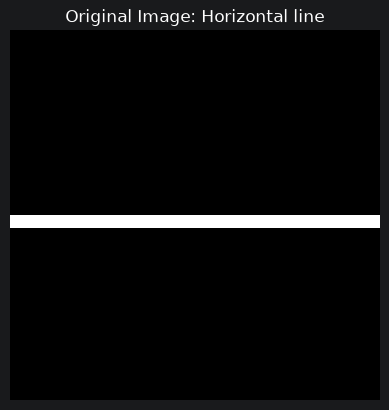

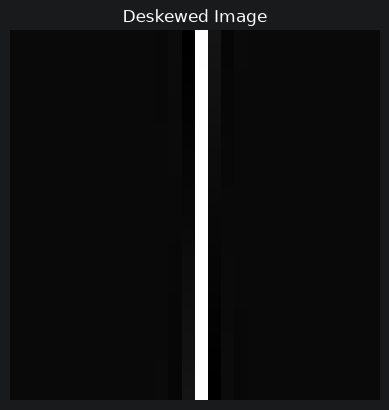

In [2]:
import numpy as np
from skimage.measure import moments, moments_central
from scipy.ndimage import rotate
import matplotlib.pyplot as plt

#  Tworzymy obraz 28x28 z poziomą linią w środku
img = np.zeros((28, 28))
img[14, :] = 1.0

plt.imshow(img, cmap='gray')
plt.title("Original Image: Horizontal line")
plt.axis('off')
plt.show()


# Deskew function z wypisaniem momentów użytych do obrotu
def deskew_image_verbose(img):
    m = moments(img)
    if m[0, 0] == 0:
        return img
    cx = m[1, 0] / m[0, 0]
    cy = m[0, 1] / m[0, 0]
    mu = moments_central(img, center=(cy, cx))

    # momenty użyte do kąta
    mu_11 = mu[1, 1]
    mu_20 = mu[2, 0]
    mu_02 = mu[0, 2]
    # print("\nMomenty centralne użyte do kąta obrotu:")
    # print(f"mu[1,1] = {mu_11}")
    # print(f"mu[2,0] = {mu_20}")
    # print(f"mu[0,2] = {mu_02}")

    angle = 0.5 * np.arctan2(2 * mu_11, mu_20 - mu_02)
    angle_deg = np.degrees(angle)
    # print(f"Kąt obrotu: {angle_deg:.2f} stopni")

    return rotate(img, -angle_deg, reshape=False, mode='nearest')


#  Zastosowanie funkcji do obrazu
img_deskew = deskew_image_verbose(img)

plt.imshow(img_deskew, cmap='gray')
plt.title("Deskewed Image")
plt.axis('off')
plt.show()


##Każdy z tych podpunktów powinien być zrealizowany w osobnej komórce
1. Wczytaj standardowy zbiór MNIST 28x28.
2. Przeprowadź analizę klasyfikacyjną metodą knn dla tego zbioru . Pomimo wysokiej wymiarowości problemu taka prosta klasyfikacja na tym zbiorze daje dość dobre wyniki ze względu na specyfikę zbiorów
3. Przygotuj zbiór danych składający się z obróconych obrazów ze zbioru MNIST o losowe kąty w granicach $ (-\pi/2,\pi/2)$
4. Sprawdź jakość klasyfikacji knn na tym zbiorze. Wykorzystaj przynajmniej dwie różne metryki odległości
5. Zastosuj funkcję deskew_image w celu "wyprostowania" obrazów
6. Zrób (dla kilku losowo wybranych indeksów) graficzne porównanie  zbioru obrazów oryginalnych, zbioru obrazów obróconych i zbioru obrazów z kierunkiem głównym przywróconym poprzez funkcję deskew_image
7. Wykonaj klasyfikację knn dla zbioru przywróconych obrazów.

8. Wybierz kilka zdjęć dowolnych ludzkich twarzy a następnie sprawdź czy ta funkcja nadaje się do wyrównywania tego typu obrazów.

9. Przygouj kilkuzdaniowy komentarz do wyników tego laboratorium

In [3]:
import tensorflow as tf

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Convert to NumPy arrays
x_train_np = x_train.astype('float32')
x_test_np = x_test.astype('float32')

print("MNIST dataset loaded successfully:")
print(f"Training data shape: {x_train_np.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test_np.shape}")
print(f"Test labels shape: {y_test.shape}")

I0000 00:00:1782919370.057305   25621 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782919370.058509   25621 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782919370.228384   25621 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782919392.801636   25621 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

MNIST dataset loaded successfully:
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

# Reshape the images to be a flat vector
x_train_flat = x_train_np.reshape(x_train_np.shape[0], -1)
x_test_flat = x_test_np.reshape(x_test_np.shape[0], -1)

print(f"Flattened training data shape: {x_train_flat.shape}")
print(f"Flattened test data shape: {x_test_flat.shape}")

# Initialize KNN classifier (you can adjust n_neighbors)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the classifier
print("\nTraining KNN classifier...")
start_time = time.time()
knn.fit(x_train_flat, y_train)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")

# Predict on the test set
print("Predicting on the test set...")
start_time = time.time()
y_pred = knn.predict(x_test_flat)
end_time = time.time()
print(f"Prediction completed in {end_time - start_time:.2f} seconds.")

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of KNN classifier on MNIST test set: {accuracy:.4f}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)

Training KNN classifier...
Training completed in 0.05 seconds.
Predicting on the test set...
Prediction completed in 21.40 seconds.

Accuracy of KNN classifier on MNIST test set: 0.9688


In [5]:
import numpy as np
from scipy.ndimage import rotate


# Function to rotate an image by a random angle
def rotate_image_random(image):
    # Generate a random angle between -pi/2 and pi/2 radians (-90 and 90 degrees)
    angle_rad = np.random.uniform(-np.pi / 2, np.pi / 2)
    angle_deg = np.degrees(angle_rad)

    # Rotate the image
    rotated_image = rotate(image, angle_deg, reshape=False, mode='nearest')
    return rotated_image


# Create a new array to store the rotated images
x_train_rotated = np.zeros_like(x_train_np)
x_test_rotated = np.zeros_like(x_test_np)

# Rotate training images
print("Rotating training images...")
for i in range(x_train_np.shape[0]):
    x_train_rotated[i] = rotate_image_random(x_train_np[i])

# Rotate test images
print("Rotating test images...")
for i in range(x_test_np.shape[0]):
    x_test_rotated[i] = rotate_image_random(x_test_np[i])

print("Image rotation complete.")
print(f"Shape of rotated training data: {x_train_rotated.shape}")
print(f"Shape of rotated test data: {x_test_rotated.shape}")

Rotating training images...
Rotating test images...
Image rotation complete.
Shape of rotated training data: (60000, 28, 28)
Shape of rotated test data: (10000, 28, 28)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time

# --- Spłaszczenie obrazów (cały zbiór) ---
# Używamy oryginalnych, pełnych zbiorów
x_train_flat = x_train_np.reshape(x_train_np.shape[0], -1)
x_test_rotated_flat = x_test_rotated.reshape(x_test_rotated.shape[0], -1)

print(f"Flattened rotated training data shape: {x_train_flat.shape}")
print(f"Flattened rotated test data shape: {x_test_rotated_flat.shape}")

# --- KNN z odległością euklidesową ---
print("\n--- KNN with Euclidean distance ---")
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

print("Training KNN (Euclidean) on full set...")
start_time = time.time()
# Używamy pełnego y_train
knn_euclidean.fit(x_train_flat, y_train)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

print("Predicting on the full rotated test set (Euclidean)...")
start_time = time.time()
y_pred_euclidean = knn_euclidean.predict(x_test_rotated_flat)
print(f"Prediction completed in {time.time() - start_time:.2f} seconds.")

# Używamy pełnego y_test do oceny
accuracy_euclidean = accuracy_score(y_test, y_pred_euclidean)
print(f"Accuracy of KNN (Euclidean) on rotated test set: {accuracy_euclidean:.4f}")

# --- KNN z odległością Manhattan ---
print("\n--- KNN with Manhattan distance ---")
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')

print("Training KNN (Manhattan) on full set...")
start_time = time.time()
# Używamy pełnego y_train
knn_manhattan.fit(x_train_flat, y_train)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

print("Predicting on the full rotated test set (Manhattan)...")
start_time = time.time()
y_pred_manhattan = knn_manhattan.predict(x_test_rotated_flat)
print(f"Prediction completed in {time.time() - start_time:.2f} seconds.")

# Używamy pełnego y_test do oceny
accuracy_manhattan = accuracy_score(y_test, y_pred_manhattan)
print(f"Accuracy of KNN (Manhattan) on rotated test set: {accuracy_manhattan:.4f}")


Flattened rotated training data shape: (60000, 784)
Flattened rotated test data shape: (10000, 784)

--- KNN with Euclidean distance ---
Training KNN (Euclidean) on full set...
Training completed in 0.03 seconds.
Predicting on the full rotated test set (Euclidean)...
Prediction completed in 14.85 seconds.
Accuracy of KNN (Euclidean) on rotated test set: 0.5308

--- KNN with Manhattan distance ---
Training KNN (Manhattan) on full set...
Training completed in 0.02 seconds.
Predicting on the full rotated test set (Manhattan)...
Prediction completed in 107.37 seconds.
Accuracy of KNN (Manhattan) on rotated test set: 0.5277


In [7]:
# 1. Zainicjuj nowe tablice (używając zeros_like, jak w pierwotnej wersji 100%)
x_train_deskewed = np.zeros_like(x_train_rotated)
x_test_deskewed = np.zeros_like(x_test_rotated)

# --- Zbiór treningowy ---

# 2. Pobierz pełną liczbę obrazów
num_train = x_train_rotated.shape[0]

# 3. (Usunięto logikę losowego wybierania 5% indeksów)

print(f"Applying deskewing to {num_train} (100%) training images...")
# 4. Zastosuj funkcję dla wszystkich obrazów w zbiorze
for i in range(num_train):
    # Zastosuj funkcję "deskewing"
    x_train_deskewed[i] = deskew_image_verbose(x_train_rotated[i])

# --- Zbiór testowy ---

# 5. Pobierz pełną liczbę obrazów
num_test = x_test_rotated.shape[0]

# 6. (Usunięto logikę losowego wybierania 5% indeksów)

print(f"Applying deskewing to {num_test} (100%) test images...")
# 7. Zastosuj funkcję dla wszystkich obrazów w zbiorze
for i in range(num_test):
    # Zastosuj funkcję "deskewing"
    x_test_deskewed[i] = deskew_image_verbose(x_test_rotated[i])

Applying deskewing to 60000 (100%) training images...
Applying deskewing to 10000 (100%) test images...


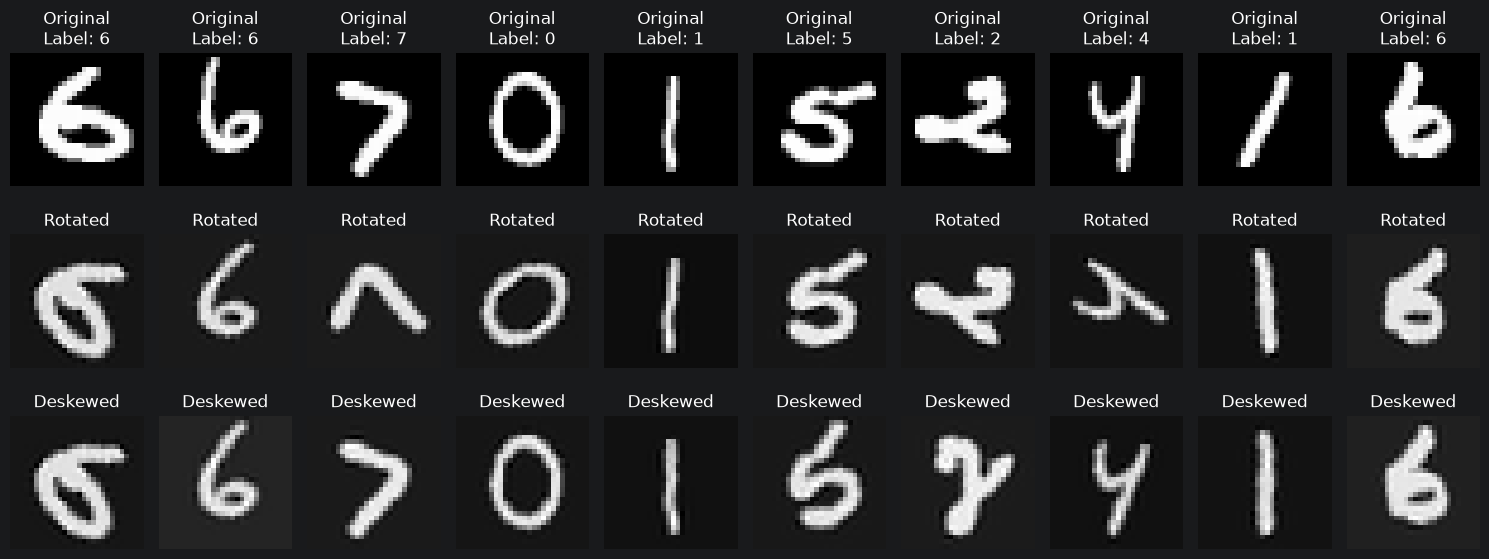

In [8]:
import matplotlib.pyplot as plt
import random

# Choose the number of examples to display
num_examples = 10

# Get random indices
random_indices = random.sample(range(x_test_np.shape[0]), num_examples)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(random_indices):
    # Original image
    plt.subplot(3, num_examples, i + 1)
    plt.imshow(x_test_np[idx], cmap='gray')
    plt.title(f"Original\nLabel: {y_test[idx]}")
    plt.axis('off')

    # Rotated image
    plt.subplot(3, num_examples, i + 1 + num_examples)
    plt.imshow(x_test_rotated[idx], cmap='gray')
    plt.title("Rotated")
    plt.axis('off')

    # Deskewed image
    plt.subplot(3, num_examples, i + 1 + 2 * num_examples)
    plt.imshow(x_test_deskewed[idx], cmap='gray')
    plt.title("Deskewed")
    plt.axis('off')

# Te funkcje powinny być wywołane PO pętli, aby sformatować cały wykres
plt.tight_layout()
plt.show()

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

# --- Użycie pełnych zbiorów danych ---
# (Usunięto sekcję train_test_split zmniejszającą zbiory)

# Spłaszczenie obrazów (cały zbiór)
x_train_deskewed_flat = x_train_deskewed.reshape(x_train_deskewed.shape[0], -1)
x_test_deskewed_flat = x_test_deskewed.reshape(x_test_deskewed.shape[0], -1)

print(f"Flattened deskewed training data shape: {x_train_deskewed_flat.shape}")
print(f"Flattened deskewed test data shape: {x_test_deskewed_flat.shape}")

# Inicjalizacja klasyfikatora KNN
knn_deskewed = KNeighborsClassifier(n_neighbors=5)

# Trenowanie klasyfikatora
print("\nTraining KNN classifier on full deskewed data...")
start_time = time.time()
# Użyj pełnych danych treningowych
knn_deskewed.fit(x_train_deskewed_flat, y_train)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds.")

# Predykcja na zbiorze testowym
print("Predicting on the full deskewed test set...")
start_time = time.time()
y_pred_deskewed = knn_deskewed.predict(x_test_deskewed_flat)
end_time = time.time()
print(f"Prediction completed in {end_time - start_time:.2f} seconds.")

# Ocena klasyfikatora
# Użyj pełnych etykiet testowych
accuracy_deskewed = accuracy_score(y_test, y_pred_deskewed)
print(f"\nAccuracy of KNN classifier on full deskewed test set: {accuracy_deskewed:.4f}")

Flattened deskewed training data shape: (60000, 784)
Flattened deskewed test data shape: (10000, 784)

Training KNN classifier on full deskewed data...
Training completed in 0.02 seconds.
Predicting on the full deskewed test set...
Prediction completed in 12.81 seconds.

Accuracy of KNN classifier on full deskewed test set: 0.9543


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/pawel/scikit_learn_data


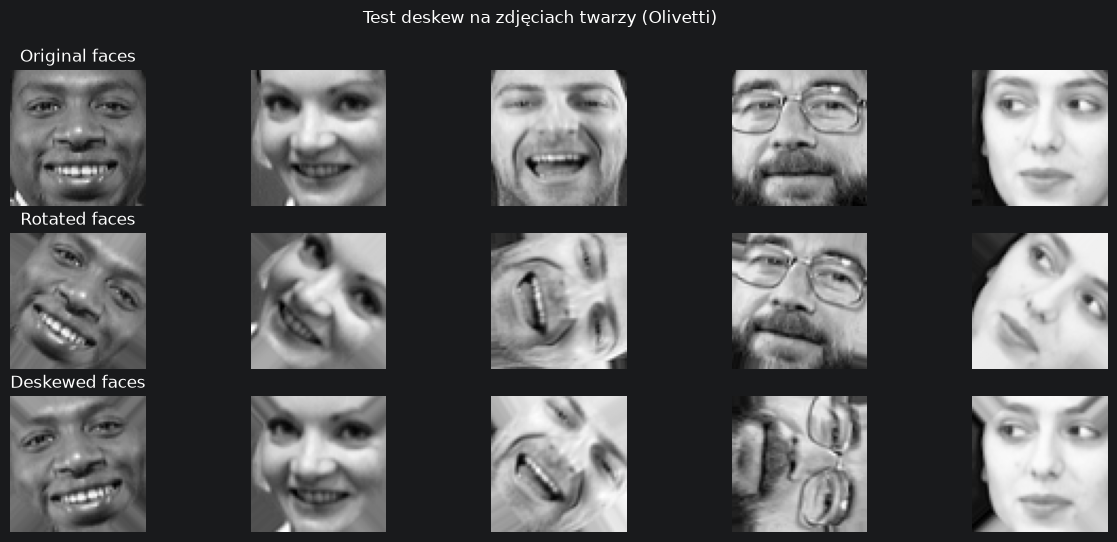

In [10]:
# Cell 8: wczytanie przykładowych zdjęć twarzy i zastosowanie deskew
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces(shuffle=True, random_state=0)
face_imgs = faces.images  # kształt (400, 64, 64), wartości w [0,1]
# wybierz kilka osób/zdjęć
#sel = [1, 11, 21, 31, 41, 51, 61]  # przykładowe indeksy
import random

num_faces_to_show = 5
sel = random.sample(range(face_imgs.shape[0]), num_faces_to_show)

#face_imgs[sel]=1-face_imgs[sel] #TEST DLA CZARNYCH TWARZY - NEGATYW

fig, axes = plt.subplots(3, len(sel), figsize=(3 * len(sel), 6))
for col, i in enumerate(sel):
    orig = face_imgs[i]
    # żeby zasymulować rotacje, najpierw obróć lekko (np. +25 deg)
    #rot = rotate(orig, 25*(col%2==0) - 15*(col%2==1), reshape=False, mode='nearest')
    rot = rotate_image_random(orig)
    desk = deskew_image_simple(rot)
    axes[0, col].imshow(orig, cmap='gray');
    axes[0, col].axis('off')
    axes[1, col].imshow(rot, cmap='gray');
    axes[1, col].axis('off')
    axes[2, col].imshow(desk, cmap='gray');
    axes[2, col].axis('off')

axes[0, 0].set_title("Original faces")
axes[1, 0].set_title("Rotated faces")
axes[2, 0].set_title("Deskewed faces")
plt.suptitle("Test deskew na zdjęciach twarzy (Olivetti)")
plt.show()

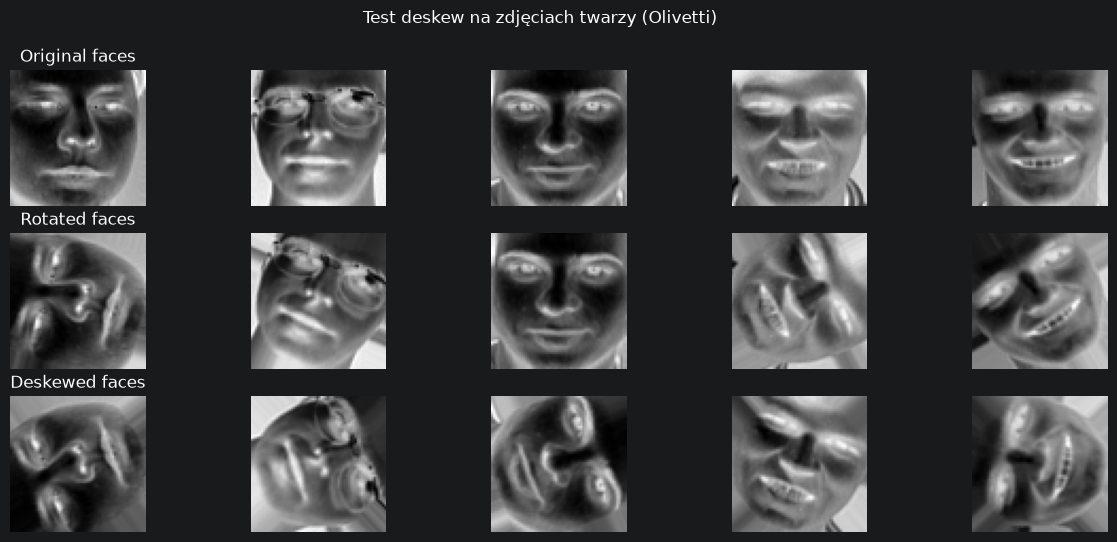

In [11]:
# Cell 8: wczytanie przykładowych zdjęć twarzy i zastosowanie deskew
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces(shuffle=True, random_state=0)
face_imgs = faces.images  # kształt (400, 64, 64), wartości w [0,1]
# wybierz kilka osób/zdjęć
#sel = [1, 11, 21, 31, 41, 51, 61]  # przykładowe indeksy
import random

num_faces_to_show = 5
sel = random.sample(range(face_imgs.shape[0]), num_faces_to_show)

face_imgs[sel]=1-face_imgs[sel] #TEST DLA CZARNYCH TWARZY - NEGATYW

fig, axes = plt.subplots(3, len(sel), figsize=(3 * len(sel), 6))
for col, i in enumerate(sel):
    orig = face_imgs[i]
    # żeby zasymulować rotacje, najpierw obróć lekko (np. +25 deg)
    #rot = rotate(orig, 25*(col%2==0) - 15*(col%2==1), reshape=False, mode='nearest')
    rot = rotate_image_random(orig)
    desk = deskew_image_simple(rot)
    axes[0, col].imshow(orig, cmap='gray');
    axes[0, col].axis('off')
    axes[1, col].imshow(rot, cmap='gray');
    axes[1, col].axis('off')
    axes[2, col].imshow(desk, cmap='gray');
    axes[2, col].axis('off')

axes[0, 0].set_title("Original faces")
axes[1, 0].set_title("Rotated faces")
axes[2, 0].set_title("Deskewed faces")
plt.suptitle("Test deskew na zdjęciach twarzy (Olivetti)")
plt.show()

Wydajność bazowa: Klasyfikator KNN zastosowany na oryginalnym,  zbiorze danych MNIST osiągnął wysoką dokładność na poziomie 96%

 Wprowadzenie losowej rotacji obrazów testowych obniżyło skuteczność klasyfikacji. Dokładność spadła z 96% do 53%. klasyfikator KNN, oparty na odległości pikseli, jest wysoce wrażliwy na zmiany orientacji obiektu

 Zastosowanie algorytmu prostowania pozwoliło na niemal pełne odzyskanie pierwotnej wydajności. Dokładność klasyfikacji na wyniosła 95%

 Graficzne porównanie obrazów potwierdziło, że algorytm skutecznie przywraca pionową orientację większości cyfr. Jednocześnie pokazało to pewne ograniczenia metody algorytm opiera się na "głównej osi bezwładności", co w przypadku "6" i "9" dochodzi do pomyłek lub obrotów o 180 stopni.

 Testy na zbiorze twarzy Olivetti wykazały, że metoda ta nie nadaje się do prostowania obrazów o bardziej złożonych lub symetrycznych kształtach

